In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

/content


In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

/content/drive/My Drive/Colab Notebooks


#### 코랩에서 한국어 표시하기

In [ ]:
!apt-get install fonts-nanum* -qq
# 다운받은 후 코랩 런타임 다시 시작

In [ ]:
%matplotlib inline  # 별도의 plt.show()를 호출하지 않아도 그래프가 노트북 내부에 자동으로 출력됨
import matplotlib.pyplot as plt
import matplotlib as mpl 

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 패치
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name

# 딥러닝 개요와 퍼셉트론

## 수업 목차 

 
[1. 딥러닝 개요](#one)<br>
- 최근 딥러닝 동향 
- 딥러닝에 기여한 인물들 
- 딥러닝 발전 흐름 

[2. Perceptron & MLP](#two)<br>
- 퍼셉트론 개념 
- 수식 유도 문제 (가중치, 바이어스 개념 설명)
- Numpy 실습 
- XOR 문제
- Scikit-learn 실습

[3. 활성화 함수](#three)<br>
- 활성화 함수의 개념 
- 활성화 함수의 종류 

[4. 역전파 알고리즘](#four)<br>
- 역전파란? 
- 역전파가 필요한 이유 
- 역전파 시각화 영상 시청 

[5. 심층 신경망의 개념과 실습](#five)<br>
- 심층 신경망이란
- Scikit-learn 실습 

[6. 딥러닝 프레임 워크 소개](#six)<br>
- Tensorflow vs PyTorch 
- 그 밖의 프레임워크 
- PyTorch 소개 및 설치 
- PyTorch 기본 활용법 

## <a id='one'>1. 딥러닝 개요</a><br>

## 최근 딥러닝 동향

### [블로그]
https://y2025story.tistory.com/entry/%EB%94%A5%EB%9F%AC%EB%8B%9D-%EC%B5%9C%EC%8B%A0-%EA%B8%B0%EC%88%A0-%EB%8F%99%ED%96%A5-%EC%97%B0%EA%B5%AC%EC%99%80-%EC%8B%A4%EC%A0%9C-%EC%A0%81%EC%9A%A9-%EC%82%AC%EB%A1%80

### [AI 챗봇에게 질문]

#### Gemini 

```
최근 딥러닝 동향은 다음과 같이 요약할 수 있습니다.

1. 거대 모델 및 초거대 AI
규모 확장: 매개변수 수가 수천억 개에 달하는 거대 모델이 등장하며, 자연어 처리, 이미지 인식 등 다양한 분야에서 뛰어난 성능을 보입니다.
초거대 AI: 다양한 분야의 데이터를 학습하여 인간과 유사한 수준의 인지 능력을 갖춘 초거대 AI 개발이 활발하게 진행되고 있습니다.

2. 생성형 AI
이미지, 영상, 텍스트 생성: 텍스트 프롬프트를 기반으로 고품질 이미지, 영상, 텍스트를 생성하는 모델들이 등장하며, 창작 분야에 혁신을 가져오고 있습니다.
다양한 분야 활용: 예술, 디자인, 콘텐츠 제작 등 다양한 분야에서 생성형 AI 활용이 확대되고 있습니다.

3. 강화 학습
복잡한 문제 해결: 강화 학습과 딥러닝을 결합한 딥 강화 학습이 복잡한 문제 해결에 강력한 성능을 발휘합니다.
자율주행, 로봇 공학: 자율주행, 게임 AI, 로봇 공학 등 다양한 분야에서 강화 학습 활용이 증가하고 있습니다.

4. 딥러닝 응용 분야 확장
의료: 의료 영상 분석, 질병 진단, 신약 개발 등 의료 분야에서 딥러닝 활용이 활발하게 이루어지고 있습니다.
자율주행: 자율주행 자동차의 인지, 판단, 제어 시스템에 딥러닝 기술이 적용되고 있습니다.
제조: 스마트 팩토리, 품질 관리, 생산 최적화 등 제조 분야에서 딥러닝 활용이 확대되고 있습니다.

5. 딥러닝 연구 방향
모델 경량화 및 효율성 향상: 모바일 기기나 저전력 환경에서도 딥러닝 모델을 사용할 수 있도록 모델 경량화 및 효율성 향상 연구가 진행되고 있습니다.
설명 가능한 AI: 딥러닝 모델의 의사 결정 과정을 설명하고 이해하기 위한 연구가 활발하게 이루어지고 있습니다.
페더레이티드 러닝: 중앙 서버에 데이터를 모으지 않고 분산된 환경에서 딥러닝 모델을 학습하는 페더레이티드 러닝 연구가 주목받고 있습니다.
```

#### ChatGPT 

```
​최근 딥러닝 분야에서는 다음과 같은 주요 동향이 나타나고 있습니다:​
1. 대규모 언어 모델의 발전: OpenAI의 GPT-4와 같은 대규모 언어 모델이 개발되어 자연어 처리 분야에서 뛰어난 성능을 보이고 있습니다. 
이러한 모델들은 번역, 요약, 질의응답 등 다양한 작업에서 활용되고 있습니다.​
2. 멀티모달 학습의 부상: 텍스트, 이미지, 음성 등 여러 유형의 데이터를 동시에 처리할 수 있는 멀티모달 모델이 주목받고 있습니다. 
이는 인간의 다양한 감각을 통합적으로 이해하는 방향으로의 발전을 의미합니다.​
3. 모델 경량화 및 효율성 향상: 딥러닝 모델의 크기와 복잡성이 증가함에 따라, 이를 경량화하고 효율성을 높이기 위한 연구가 활발히 진행되고 있습니다. 
이는 모바일 기기나 임베디드 시스템에서도 딥러닝을 활용할 수 있도록 합니다.​
4. 자율학습 및 강화학습의 발전: 라벨이 없는 데이터로부터 학습하는 자율학습(Self-Supervised Learning)과 보상을 통해 학습하는 
강화학습(Reinforcement Learning)이 더욱 발전하여, 복잡한 문제 해결에 적용되고 있습니다.​
5. 딥러닝의 산업별 적용 확대: 의료, 금융, 제조 등 다양한 산업 분야에서 딥러닝 기술이 적용되어 혁신을 이끌고 있습니다. 
예를 들어, 의료 분야에서는 질병 진단 및 신약 개발에 딥러닝이 활용되고 있습니다.​
이러한 동향들은 딥러닝 기술이 지속적으로 발전하며 우리의 일상과 산업 전반에 큰 영향을 미치고 있음을 보여줍니다.
```

#### Grok3 

```
최근 딥러닝 동향을 간단히 요약하면, 몇 가지 주요 흐름이 눈에 띕니다. 
먼저, 대규모 언어 모델(LLM)이 여전히 주목받고 있으며, 더 효율적이고 특정 작업에 특화된 모델로 진화 중입니다. 
예를 들어, 오픈소스 커뮤니티에서 경량화된 모델들이 인기를 끌고 있어요. 
두 번째로, 멀티모달 학습이 뜨고 있습니다. 텍스트, 이미지, 음성 등을 통합적으로 처리하는 모델들이 점점 발전하면서 실생활 응용 가능성이 커지고 있죠. 
세 번째로는 자율 학습이나 강화 학습과의 융합이 두드러지는데, 데이터 효율성을 높이고 인간의 개입을 줄이는 방향으로 가고 있습니다. 
마지막으로, 윤리적 AI와 설명 가능성(Explainability)에 대한 관심도 계속 증가하며, 모델의 투명성과 공정성을 확보하려는 노력이 병행되고 있어요. 
딥러닝은 여전히 빠르게 진화 중이라 흥미로운 시점입니다!
```

## 딥러닝에 기여한 인물들 

<img src="사진/person.png" alt="person"/>

[얀 르쿤 - AGI]
- https://www.thepickool.kr/p/agi-ai

[허사비스 - AGI]
- https://www.yna.co.kr/view/AKR20250318006300091?section=people/ceo

[인공지능 거장]
- https://brunch.co.kr/@hvnpoet/66

[조경현 교수] 
- https://brunch.co.kr/@hvnpoet/127

[국내외 ai 유명인사]
- https://sunnycloudstory.tistory.com/126

## <a id='two'>2. Perceptron & MLP</a><br>

## Perceptron

> 퍼셉트론(Perceptron)은 가장 기본적인 인공 신경망 모델로, Frank Rosenblatt(1958년) 에 의해 제안된 개념 <br> 
> 마치 뉴런의 행동 방식을 수학적으로 단순화 한 모델 

<img src="사진/perceptron.png" alt="perceptron"/>

w: 가중치(Weight) → 신호의 중요도를 조절 <br>
x: 입력 값(Feature) <br>
b: 바이어스(Bias) → 모델의 조정 가능성 추가 <br>
f: 활성화 함수(Activation Function)

비교 항목|	생물학적 뉴런 (Neuron)	| 퍼셉트론 (Perceptron)
---|---|---
신호 전달 방식|	전기 신호(Spike) & 화학적 신호	|수학적 연산(가중치 곱셈 + 활성화 함수)
입력 값 처리|	신경 네트워크를 통해 비선형 정보 전달	|선형 연산 후 활성화 함수를 적용
출력 방식|	연속적인 전압 변화	|0 또는 1 (이진 분류)
학습 방식|	뇌의 가소성(Plasticity) → 반복 학습	|가중치 조정(Gradient Descent, Backpropagation)
복잡성|	수십억 개의 뉴런 연결	|단순한 수학적 연산 모델

### Linear model과 Perceptron의 차이

비교 항목|	Linear Model (선형 모델)|	Perceptron (퍼셉트론)
---|---|---
출력 값|	연속적인 값 (실수)|	이진 분류 (0 또는 1)
활성화 함수|	없음 (또는 확률 값 출력)|	있음 (계단 함수, 시그모이드 등)
사용 분야|	회귀(Regression), 선형 분류(Linear Classification)|	이진 분류(Binary Classification)
가중치 업데이트|	경사 하강법(Gradient Descent) 사용|	단순한 가중치 업데이트 규칙

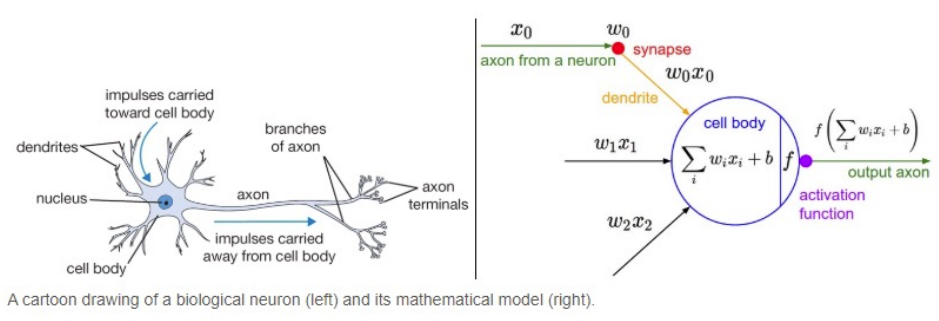

### 퍼셉트론 학습 방법

1. 가중치(w), 편향(b)를 0 또는 작은 랜덤 값 그리고 학습률(η)을 초기화 한다 
2. 입력 데이터를 받는다
3. 입력값과 가중치를 곱하고 바이어스를 더해서 연산한다. 그리고 활성화 함수를 적용한다. (순전파: 입력에서 출력까지 전달되는 과정)
4. 실제 값과 예측값의 오차를 구한다 
5. 가중치를 업데이트 한다 
6. 편향을 업데이트 한다
7. 반복한다

가중치, 편향 업데이트 방법

<img src="사진/update.png" alt="update"/>

### AND, OR 게이트 만들기

[참고] https://m.blog.naver.com/junb7/222792228046

In [7]:
import numpy as np

# 초기 가중치와 편향 설정
w1, w2, b = 0.0, 0.0, 0.0
learning_rate = 0.1

def activation(x):
    return 1 if x >= 0 else 0

# 학습 데이터 (AND 연산)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# 10번 반복 학습
for epoch in range(10):
    print(f"Epoch {epoch+1}")
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y[i]
        
        # 가중치 적용하여 출력 계산
        output = activation(w1*x1 + w2*x2 + b)
        
        # 오차 계산
        error = target - output
        
        # 가중치 및 편향 업데이트
        w1 += learning_rate * error * x1
        w2 += learning_rate * error * x2
        b += learning_rate * error
        
        print(f"입력: {x1, x2}, 예측: {output}, 정답: {target}, 가중치: ({w1:.2f}, {w2:.2f}), 편향: {b:.2f}")
    print("-")

# 학습된 퍼셉트론 테스트
print("최종 퍼셉트론 결과:")
for x1, x2 in X:
    result = activation(w1*x1 + w2*x2 + b)
    print(f"입력: {x1, x2} -> 예측: {result}")

print("최종 가중치 및 편향: ",w1, w2, b)

Epoch 1
입력: (0, 0), 예측: 1, 정답: 0, 가중치: (0.00, 0.00), 편향: -0.10
입력: (0, 1), 예측: 0, 정답: 0, 가중치: (0.00, 0.00), 편향: -0.10
입력: (1, 0), 예측: 0, 정답: 0, 가중치: (0.00, 0.00), 편향: -0.10
입력: (1, 1), 예측: 0, 정답: 1, 가중치: (0.10, 0.10), 편향: 0.00
-
Epoch 2
입력: (0, 0), 예측: 1, 정답: 0, 가중치: (0.10, 0.10), 편향: -0.10
입력: (0, 1), 예측: 1, 정답: 0, 가중치: (0.10, 0.00), 편향: -0.20
입력: (1, 0), 예측: 0, 정답: 0, 가중치: (0.10, 0.00), 편향: -0.20
입력: (1, 1), 예측: 0, 정답: 1, 가중치: (0.20, 0.10), 편향: -0.10
-
Epoch 3
입력: (0, 0), 예측: 0, 정답: 0, 가중치: (0.20, 0.10), 편향: -0.10
입력: (0, 1), 예측: 1, 정답: 0, 가중치: (0.20, 0.00), 편향: -0.20
입력: (1, 0), 예측: 1, 정답: 0, 가중치: (0.10, 0.00), 편향: -0.30
입력: (1, 1), 예측: 0, 정답: 1, 가중치: (0.20, 0.10), 편향: -0.20
-
Epoch 4
입력: (0, 0), 예측: 0, 정답: 0, 가중치: (0.20, 0.10), 편향: -0.20
입력: (0, 1), 예측: 0, 정답: 0, 가중치: (0.20, 0.10), 편향: -0.20
입력: (1, 0), 예측: 0, 정답: 0, 가중치: (0.20, 0.10), 편향: -0.20
입력: (1, 1), 예측: 1, 정답: 1, 가중치: (0.20, 0.10), 편향: -0.20
-
Epoch 5
입력: (0, 0), 예측: 0, 정답: 0, 가중치: (0.20, 0.10), 편향: -0.20
입력: (0, 1), 예측: 0,

In [23]:
import numpy as np

# 초기 가중치 및 편향 설정
W = np.zeros(2)  # w1, w2를 하나의 벡터로 저장
b = 0.0
learning_rate = 0.1

def activation(x):
    return np.where(x >= 0, 1, 0)  # 벡터 연산을 위해 np.where 사용

# 학습 데이터 (AND 연산)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # 입력 값
y = np.array([0, 0, 0, 1])  # 정답 레이블

# 10번 반복 학습
for epoch in range(3):
    print(f"Epoch {epoch+1}")
    
    # 선형 결합 및 활성화 함수 적용
    outputs = activation(np.dot(X, W) + b)
    
    # 오차 계산
    errors = y - outputs
    
    # 가중치 및 편향 업데이트 (벡터 연산)
    W += learning_rate * np.dot(errors, X)
    b += learning_rate * np.sum(errors)
    
    # 학습 과정 출력
    for i in range(len(X)):
        print(f"입력: {tuple(X[i])}, 예측: {outputs[i]}, 정답: {y[i]}, 가중치: {tuple(W)}, 편향: {b:.2f}")
    print("-")

# 학습된 퍼셉트론 테스트
print("최종 퍼셉트론 결과:")
final_outputs = activation(np.dot(X, W) + b)
for i in range(len(X)):
    print(f"입력: {tuple(X[i])} -> 예측: {final_outputs[i]}")

print("최종 가중치 및 편향: ", W, b)

Epoch 1
입력: (np.int64(0), np.int64(0)), 예측: 1, 정답: 0, 가중치: (np.float64(-0.1), np.float64(-0.1)), 편향: -0.30
입력: (np.int64(0), np.int64(1)), 예측: 1, 정답: 0, 가중치: (np.float64(-0.1), np.float64(-0.1)), 편향: -0.30
입력: (np.int64(1), np.int64(0)), 예측: 1, 정답: 0, 가중치: (np.float64(-0.1), np.float64(-0.1)), 편향: -0.30
입력: (np.int64(1), np.int64(1)), 예측: 1, 정답: 1, 가중치: (np.float64(-0.1), np.float64(-0.1)), 편향: -0.30
-
Epoch 2
입력: (np.int64(0), np.int64(0)), 예측: 0, 정답: 0, 가중치: (np.float64(0.0), np.float64(0.0)), 편향: -0.20
입력: (np.int64(0), np.int64(1)), 예측: 0, 정답: 0, 가중치: (np.float64(0.0), np.float64(0.0)), 편향: -0.20
입력: (np.int64(1), np.int64(0)), 예측: 0, 정답: 0, 가중치: (np.float64(0.0), np.float64(0.0)), 편향: -0.20
입력: (np.int64(1), np.int64(1)), 예측: 0, 정답: 1, 가중치: (np.float64(0.0), np.float64(0.0)), 편향: -0.20
-
Epoch 3
입력: (np.int64(0), np.int64(0)), 예측: 0, 정답: 0, 가중치: (np.float64(0.1), np.float64(0.1)), 편향: -0.10
입력: (np.int64(0), np.int64(1)), 예측: 0, 정답: 0, 가중치: (np.float64(0.1), np.float64(0.1)), 편향: 

In [3]:
import numpy as np
from sklearn.linear_model import Perceptron

# 학습 데이터 (AND 연산)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND 연산 결과

# 단층 퍼셉트론 모델 생성 및 학습
perceptron = Perceptron(max_iter=10, eta0=0.1, random_state=42)
perceptron.fit(X, y)

# 학습된 퍼셉트론 결과 확인
print("최종 퍼셉트론 결과:")
for x in X:
    prediction = perceptron.predict([x])[0]
    print(f"입력: {x} -> 예측: {prediction}")


최종 퍼셉트론 결과:
입력: [0 0] -> 예측: 0
입력: [0 1] -> 예측: 0
입력: [1 0] -> 예측: 0
입력: [1 1] -> 예측: 1


### Quiz1. 

> 퍼셉트론을 활용해서 OR Gate를 만드시오

In [17]:
import numpy as np

learning_rate = 0.1
w1, w2, b = 0, 0, 0

x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 1])

def zeroOne(x):
    return 1 if x > 0 else 0

for epoch in range(10):
    print(f"epoch {epoch} is start")
    for i, j in zip(x, y):
        result = w1 * i[0] + w2 * i[1] + b

        error = j - zeroOne(result)

        w1 += learning_rate * error * i[0]
        w2 += learning_rate * error * i[1]
        b += learning_rate * error

        print(f"w1: {w1}, w2: {w2}, b: {b}")

print("\nFinal result!")
for i, j in zip(x, y):
    result = w1 * i[0] + w2 * i[1] + b
    print(f"x = [{i[0]}, {i[1]}], predict = {zeroOne(result)}, y = {j}")

epoch 0 is start
w1: 0.0, w2: 0.0, b: 0.0
w1: 0.0, w2: 0.1, b: 0.1
w1: 0.0, w2: 0.1, b: 0.1
w1: 0.0, w2: 0.1, b: 0.1
epoch 1 is start
w1: 0.0, w2: 0.1, b: 0.0
w1: 0.0, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.1
w1: 0.1, w2: 0.1, b: 0.1
epoch 2 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 3 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 4 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 5 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 6 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 7 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0.0
epoch 8 is start
w1: 0.1, w2: 0.1, b: 0.0
w1: 0.1, w2: 0.1, b: 0

In [ ]:
# OR 게이트

import numpy as np
from sklearn.linear_model import Perceptron

x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 1])

perceptron = Perceptron(max_iter=10, eta0=0.1, random_state=42)
perceptron.fit(x, y)

for i, j in zip(x, y):
    print(f"{i[0]} or {i[1]} = {j}")

0 or 0 = 0
0 or 1 = 1
1 or 0 = 1
1 or 1 = 1


### Quiz2. 

> 퍼셉트론을 활용해서 XOR Gate를 만드시오

In [38]:
# XOR 모듈은 perceptron이 선형임으로 선이 2개 이상이거나 곡선이 아닌이상 불가능하다.

import numpy as np

w1, w2, b = 0, 0, 0
learning_rate = 0.1

x = np.array([[0, 1], [1, 0], [0, 0], [1, 1]])
y = np.array([1, 1, 0, 0])

def zeroOne(x):
    return 1 if x >= 0 else 0

for epoch in range(50):
    print(f"epoch {epoch + 1} is start!")
    for (i, j), k in zip(x, y):
        result = w1 * i + w2 * j + b

        error = k - zeroOne(result)

        w1 += learning_rate * error * i
        w2 += learning_rate * error * j
        b += learning_rate * error

        # print(f"x = [{i}, {j}], predict = {zeroOne(result)}, y = {k}")
        print(f"x = [{i}, {j}], y = {k}, predict = {zeroOne(result)}, w1 = {w1}, w2 = {w2}, b = {b}")

print("\nFinal predict!")
for (i, j), k in zip(x, y):
    predict = zeroOne(w1 * i + w2 * j + b)
    print(f"x = [{i}, {j}], predict = {predict}, y = {k}")


epoch 1 is start!
x = [0, 1], y = 1, predict = 1, w1 = 0.0, w2 = 0.0, b = 0.0
x = [1, 0], y = 1, predict = 1, w1 = 0.0, w2 = 0.0, b = 0.0
x = [0, 0], y = 0, predict = 1, w1 = 0.0, w2 = 0.0, b = -0.1
x = [1, 1], y = 0, predict = 0, w1 = 0.0, w2 = 0.0, b = -0.1
epoch 2 is start!
x = [0, 1], y = 1, predict = 0, w1 = 0.0, w2 = 0.1, b = 0.0
x = [1, 0], y = 1, predict = 1, w1 = 0.0, w2 = 0.1, b = 0.0
x = [0, 0], y = 0, predict = 1, w1 = 0.0, w2 = 0.1, b = -0.1
x = [1, 1], y = 0, predict = 1, w1 = -0.1, w2 = 0.0, b = -0.2
epoch 3 is start!
x = [0, 1], y = 1, predict = 0, w1 = -0.1, w2 = 0.1, b = -0.1
x = [1, 0], y = 1, predict = 0, w1 = 0.0, w2 = 0.1, b = 0.0
x = [0, 0], y = 0, predict = 1, w1 = 0.0, w2 = 0.1, b = -0.1
x = [1, 1], y = 0, predict = 1, w1 = -0.1, w2 = 0.0, b = -0.2
epoch 4 is start!
x = [0, 1], y = 1, predict = 0, w1 = -0.1, w2 = 0.1, b = -0.1
x = [1, 0], y = 1, predict = 0, w1 = 0.0, w2 = 0.1, b = 0.0
x = [0, 0], y = 0, predict = 1, w1 = 0.0, w2 = 0.1, b = -0.1
x = [1, 1], y =

## MLP(Multi Layer Perceptron)

> 3개의 퍼셉트론이 결합된 구조의 인공신경망 <br>
> 입력층, 은닉층, 출력층으로 구성되어 있다. 

<img src="사진/mlp.png" alt="mlp"/>

## XOR

In [24]:
import numpy as np

def and1(x1:int, x2:int)->int:
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    temp = np.sum(x*w) + b
    return (lambda x:1 if 1/(1 + np.exp(-x)) > 0.5 else 0)(temp)

def or1(x1:int, x2:int)->int:
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.1
    temp = np.sum(w*x) + b
    return (lambda x: 1 if 1/(1 + np.exp(-x)) > 0.5 else 0)(temp)

def nand(x1:int, x2:int)->int:
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.7
    temp = np.sum(x*w) + b
    return (lambda x:1 if 1/(1 + np.exp(-x)) > 0.5 else 0)(temp)

def xor(x1:int, x2:int)->int:
    s1 = nand(x1,x2)
    s2 = or1(x1,x2)
    result = and1(s1,s2)
    return result

In [ ]:
xor(0,1), xor(1,0), xor(0,0), xor(1,1)

(1, 1, 0, 0)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# train data (XOR Problem)
x = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

# Intialization

# input - hidden layer
w1 = np.random.randn(2,2)
b1 = np.random.randn(1,2)

# hidden - output layer
w2 = np.random.randn(1,2)
b2 = np.random.randn(1)

# epoch
ep = 30000
# learning rate
lr = 1
mse = []

# Neural Networks 2-2-1
for i in range(ep):
    
    E  = np.array([])
    result = np.array([])
    
    for j in range(len(x)):
        Ha = np.array([])
        
        # feedforward
        # input - hidden layer
        for k in range(len(w1)):
            Ha = np.append(Ha,1 / (1 + np.exp(-(np.sum(x[j] * w1[k]) + b1[0][k]))))
        
        # hideen - output layer
        Hb = 1 / (1 + np.exp(-(np.sum(Ha * w2) + b2)))
        
        # error
        E = np.append(E,y[j] - Hb)
        result = np.append(result,Hb)
        
        # back-propagation
        # output - hidden layer
        alpha_2 = E[j] * Hb * (1-Hb)
        
        # hidden - input layer
        alpha_1 = alpha_2 * Ha * (1-Ha) * w2
        
        # update
        w2 = w2 + (lr * alpha_2 * Ha)
        b2 = b2 + lr * alpha_2
        
        w1 = w1 + np.ones((2,2)) * lr * alpha_1 * x[j]
        b1 = b1 +  lr * alpha_1
    if i%1000 == 0:    
      print('EPOCH : %05d MSE : %04f RESULTS : 0 0 => %04f 0 1 => %04f 1 0 => %04f 1 1 => %04f'
          %(i,np.mean(E**2),result[0],result[1],result[2],result[3]))
    
    mse.append(np.mean(E**2))

EPOCH : 00000 MSE : 0.297931 RESULTS : 0 0 => 0.688590 0 1 => 0.686460 1 0 => 0.593977 1 1 => 0.674098
EPOCH : 01000 MSE : 0.002033 RESULTS : 0 0 => 0.048237 0 1 => 0.959690 1 0 => 0.946486 1 1 => 0.036281
EPOCH : 02000 MSE : 0.000799 RESULTS : 0 0 => 0.029993 0 1 => 0.974224 1 0 => 0.966871 1 1 => 0.023129
EPOCH : 03000 MSE : 0.000491 RESULTS : 0 0 => 0.023416 0 1 => 0.979660 1 0 => 0.974138 1 1 => 0.018264
EPOCH : 04000 MSE : 0.000353 RESULTS : 0 0 => 0.019797 0 1 => 0.982698 1 0 => 0.978125 1 1 => 0.015552
EPOCH : 05000 MSE : 0.000275 RESULTS : 0 0 => 0.017435 0 1 => 0.984698 1 0 => 0.980723 1 1 => 0.013767
EPOCH : 06000 MSE : 0.000225 RESULTS : 0 0 => 0.015742 0 1 => 0.986141 1 0 => 0.982585 1 1 => 0.012480
EPOCH : 07000 MSE : 0.000190 RESULTS : 0 0 => 0.014454 0 1 => 0.987244 1 0 => 0.984001 1 1 => 0.011495
EPOCH : 08000 MSE : 0.000164 RESULTS : 0 0 => 0.013432 0 1 => 0.988122 1 0 => 0.985124 1 1 => 0.010712
EPOCH : 09000 MSE : 0.000145 RESULTS : 0 0 => 0.012596 0 1 => 0.988843 1 

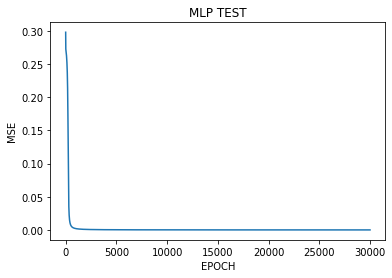

In [ ]:
plt.xlabel('EPOCH')
plt.ylabel('MSE')
plt.title('MLP TEST')
plt.plot(mse)
plt.show()

## <a id='three'>3. 활성화 함수</a><br> 

> 입력 신호의 총합을 출력신호로 변환하는 함수를 활성화 함수(Activation Functio)라 한다 <br>
> 활성화 함수를 사용하는 이유는 모델에 비선형적 특성을 부여하여 복잡한 문제를 해결 할 수 있도록 하기 위해서 이다

### Activation function 종류 

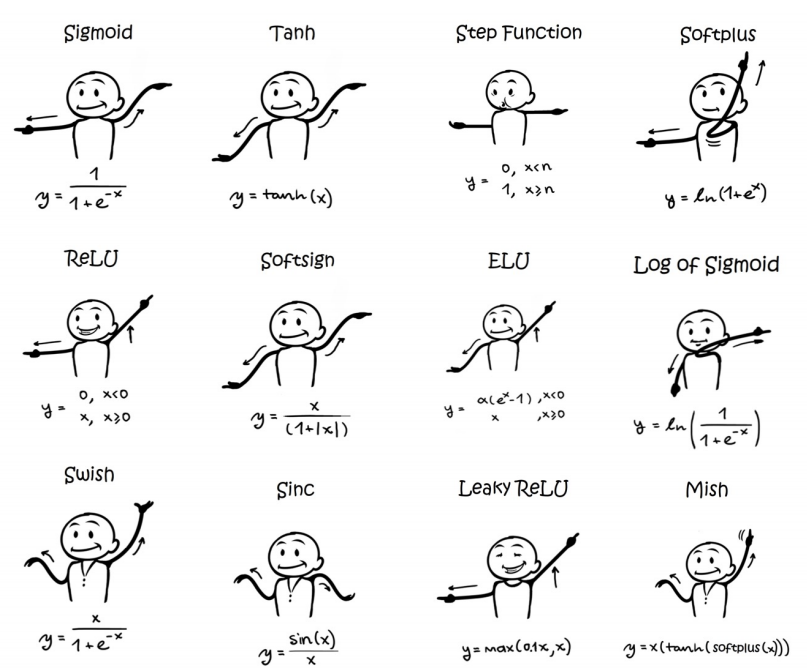

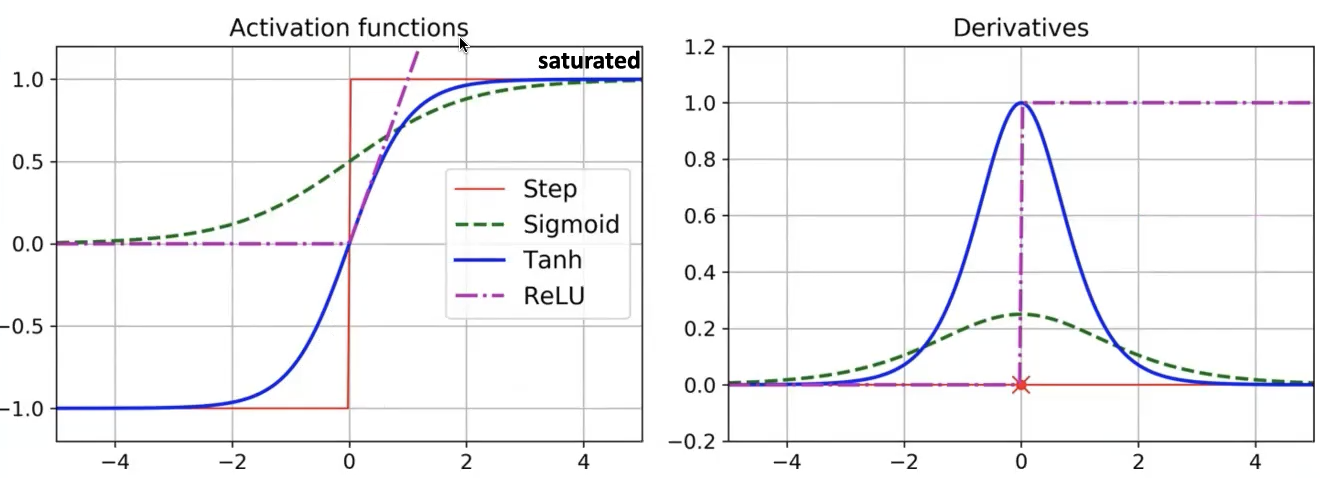

### 선형 변환 
> 어떠한 특정 벡터를 행렬 연산을 했을때 선형성이 유지가 되는 변환 <br> 

https://blog.naver.com/spin898/221139853857

In [ ]:
input_data = np.array([-1, 2]) # 2x1 / 입력 값 2개 
output_data = np.array([5, 2]) # 2x1 / 출력 값 2개 
linear_matrix = np.array([[1, 3], [-2, 0]]) # 2x2 / 입력값 2개일 때 출력값 2개를 내야 하기 때문에 가중치 행렬의 크기는 2x2 

In [59]:
linear_matrix @ input_data

array([5, 2])

<img src="사진/linear.png" alt="linear"/>

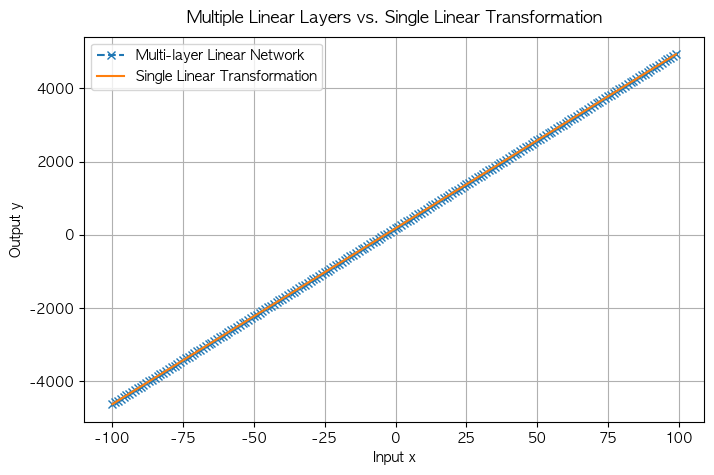

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# 입력 데이터 생성 (x 범위 설정)
x = np.arange(-100, 100)

W1, b1 = 2, 7 
W2, b2 = 3, 5  
W3, b3 = 1, -6

# 선형 활성화 함수 (원래는 비선형이지만, 여기서는 선형으로 설정)
def linear_activation(x):
    return 2*x

# 여러 층을 거치는 함수 (선형 변환 -> 선형 활성화 -> 선형 변환 반복)
def multi_layer_linear_network(x):
    # 층을 거치면서 변환 수행
    h1 = linear_activation(W1 * x + b1) # h1 = 2(W1x + b1) 
    h2 = linear_activation(W2 * h1 + b2) # h2 = 2(W2(2(W1x + b1)) + b2) 
    y = linear_activation(W3 * h2 + b3) # y = 2(W3(2(W2(2(W1x + b1)) + b2)) + b3) -> 2*2*2*W3*W2*W1*x + 2*2*2*W3*W2*b1 + 2*2*W3*b2 + 2b3 

    return y

# 단일 선형 변환 
def single_linear_transformation(x):
    W_final = 2*2*2*W3*W2*W1  # 모든 가중치를 곱한 값
    b_final = (2*2*2*W3*W2*b1) + (2*2*W3*b2) + (2 * b3)  # 모든 바이어스  / 2*2*2*W3*W2*b1 + 2*2*W3*b2 + 2b3
    return W_final * x + b_final

# 결과 계산
y_multi_layer = multi_layer_linear_network(x)
y_single_layer = single_linear_transformation(x)

# 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(x, y_multi_layer, label="Multi-layer Linear Network", linestyle="dashed", marker='x')
plt.plot(x, y_single_layer, label="Single Linear Transformation", linestyle="solid")
plt.legend()
plt.xlabel("Input x")
plt.ylabel("Output y")
plt.title("Multiple Linear Layers vs. Single Linear Transformation")
plt.grid()
plt.show()

## <a id='four'>4. 역전파 알고리즘</a><br> 

> 인공신경망에서 가중치를 효율적으로 조정하는 핵심 알고리즘 <br>
> 예측값과 정답간의 오차를 최소화 하기 위해서 오차를 거꾸로 전파하면서 각 가중치의 기울기를 계산하는 방법 <br>
> 직관적 이해: 틀린 부분을 찾아내고 조금씩 더 나아지도록 수정하는 과정

#### 순전파 
> 데이터를 입력하고 출력값을 계산하는 과정 

#### 역전파 
> 실제 값과 예측 값의 차이를 계산해서 가중치를 조정하는 과정 

#### 💡 왜 굳이 거꾸로 돌아가면서 가중치 값을 조절하는 걸까? 그냥 오차의 크기나 부호에 따라서 가중치와 바이어스를 조금씩 수정하면 되는거 아닌가? 

#### 손실함수 (Loss function)
> 신경망이 학습을 할때 얼마나 틀렸는지 측정하기 위한 함수. <br>
> 아래 예시는 MSE(Mean Squared Error) 

### 가중치가 업데이트 되는 과정
```
1. 순전파를 거쳐 예측값이 출력된다. 
2. 사전에 정의된 비용함수(손실함수)에 실제 값과 예측값을 대입하여 오차를 계산한다 
3. 출력층에서 손실함수의 기울기를 계산한다. 
4. 출력층에서 시작하여 각 층의 가중치에 대한 기울기를 구한다.
5. 체인룰을 적용하여 각 층에서 구한 기울기값으로 가중치 변화량에 대한 오차변화량을 구한다. 
6. 경사하강법을 이용하여 가중치를 조정한다. 
7. 학습이 완료될때 까지 1번부터 6번까지를 반복한다
```

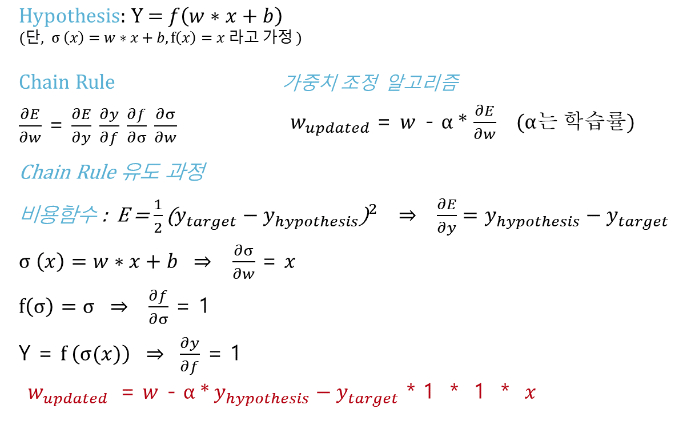

> ※ 학습률은 사람이 직접 지정해줘야 한다 <br>
> ※ 경사하강법 <br>
>   - 손실 함수의 기울기를 이용하여 오차가 줄어드는 방향으로 가중치를 점진적으로 조정하는 최적화 알고리즘
>   - 손실함수의 기울기가 0에 가까워질때 까지 가중치를 조절하는 방법

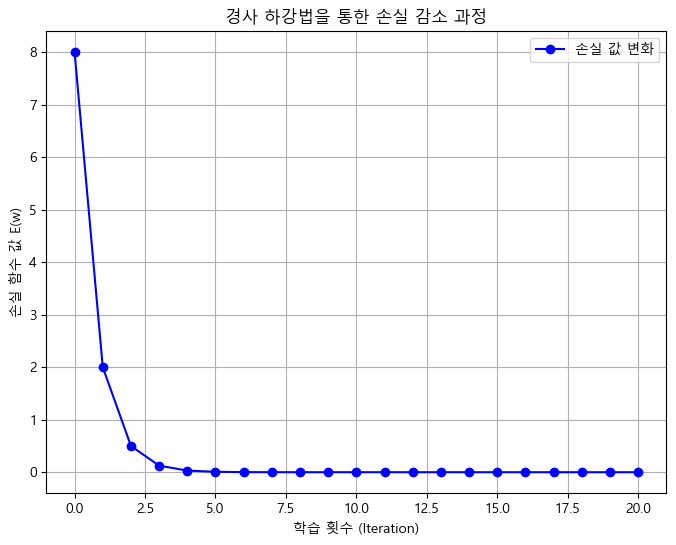

최종 가중치 (w): 3.4000015258789062
최종 바이어스 (b): -0.799999237060547
최종 손실 함수 값: 7.275957614183426e-12


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

# 한글 폰트 설정 (Windows에서는 'Malgun Gothic', Mac에서는 'AppleGothic' 등을 사용)
rc('font', family='Malgun Gothic')  # 윈도우 환경에서 '맑은 고딕' 사용

# 1. 가설 함수: Y = w * x + b
def hypothesis(w, x, b):
    return w * x + b

# 2. 비용 함수: 평균제곱오차 (MSE)
def loss_function(y_target, y_pred):
    return 0.5 * (y_target - y_pred) ** 2  # 1/2 * (y_target - y_pred)^2

# 3. 기울기(Gradient) 계산 (체인 룰 적용)
def gradient(x, y_target, w, b):
    y_pred = hypothesis(w, x, b)
    dE_dy = y_pred - y_target  # ∂E/∂y
    dy_dw = x  # ∂σ/∂w
    dy_db = 1  # ∂σ/∂b
    return dE_dy * dy_dw, dE_dy * dy_db  # (기울기 w, 기울기 b)

# 4. 학습 설정
learning_rate = 0.1  # 학습률
iterations = 20  # 학습 횟수
w = 5  # 초기 가중치 (손실이 발생하도록 설정)
b = 0  # 초기 바이어스
x = 2  # 입력값
y_target = 6  # 실제 출력값

# 5. 학습 과정 저장 (그래프 그리기용)
w_values = [w]
b_values = [b]
loss_values = [loss_function(y_target, hypothesis(w, x, b))]

# 6. 경사 하강법 실행 (업데이트 과정)
for _ in range(iterations):
    grad_w, grad_b = gradient(x, y_target, w, b)  # 기울기 계산
    w -= learning_rate * grad_w  # 가중치 업데이트
    b -= learning_rate * grad_b  # 바이어스 업데이트
    w_values.append(w)  # 업데이트된 가중치 저장
    b_values.append(b)  # 업데이트된 바이어스 저장
    loss_values.append(loss_function(y_target, hypothesis(w, x, b)))  # 손실 저장

# 7. 손실 함수 값 감소 과정 시각화
plt.figure(figsize=(8, 6))
plt.plot(range(iterations + 1), loss_values, marker='o', linestyle='-', color='blue', label="손실 값 변화")
plt.xlabel("학습 횟수 (Iteration)")
plt.ylabel("손실 함수 값 E(w)")
plt.title("경사 하강법을 통한 손실 감소 과정")
plt.legend()
plt.grid()
plt.show()

# 8. 최종 손실 값 출력
print("최종 가중치 (w):", w)
print("최종 바이어스 (b):", b)
print("최종 손실 함수 값:", loss_values[-1])

In [42]:
w_values

[5,
 4.2,
 3.8000000000000003,
 3.6,
 3.5,
 3.45,
 3.4250000000000003,
 3.4125,
 3.40625,
 3.403125,
 3.4015625000000003,
 3.40078125,
 3.400390625,
 3.4001953125,
 3.4000976562500003,
 3.400048828125,
 3.4000244140625,
 3.40001220703125,
 3.4000061035156253,
 3.4000030517578126,
 3.4000015258789062]

### Quiz3. 개념 O/X 문제 

[Q1] 역전파 알고리즘은 출력층에서 입력층 방향으로 진행된다. <br>
[Q2] 경사 하강법은 항상 최적의 0값으로 수렴한다. <br>
[Q3] 손실 함수의 기울기가 0이면 반드시 최적의 가중치 값이다. <br>

### Quiz4.

```
[Q4] 역전파에서 체인 룰을 적용하는 이유는 무엇인가?
(A) 손실 함수를 직접 미분할 수 없기 때문
(B) 여러 층을 거친 신경망의 기울기를 단계적으로 계산하기 위해
(C) 활성화 함수의 영향을 제거하기 위해
(D) 학습 속도를 빠르게 하기 위해
```

[Q5] 경사 하강법에서 학습률(α)을 너무 크게 설정하면 어떤 문제가 발생할 수 있는가?

[Q6] 가중치 업데이트 과정 계산 문제
```
다음과 같은 상황에서 1회 경사 하강법 업데이트 후 새로운 가중치를 계산하시오.
초기 가중치 w = 4 
입력값 x = 2 
정답값 target = 10 

가설함수 y = w*x + 1
학습률 α = 0.1 
```

In [ ]:
4.2

## <a id='five'>5. 심층신경망의 개념과 실습</a><br> 

## 심층 신경망
> 최소 은닉층 2개이상을 가지는 신경망 <br> 

### 왜 초기 다층퍼셉트론이 나왔을때 여러 층을 쌓을 생각을 못했을까? 

1. 기울기가 손실되는 문제가 발생
2. 하드웨어가 뒷받침되지 못했음
3. 다층퍼셉트론이 나온 뒤에 시간차로 역전파 알고리즘이 생겨남

### Scikit-learn을 활용한 심층 신경망(DNN) -> Deep Neuron Network

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 로드 및 전처리
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
X_train.shape, y_train.shape

((120, 4), (120,))

In [ ]:
X_train

In [60]:
# 2. 심층 신경망 모델 생성
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),  # 은닉층 2개 (64개 뉴런, 32개 뉴런) / 뉴런 -> 보통 노드라고함 
                    activation='relu',           # 활성화 함수: ReLU
                    solver='adam',               # 옵티마이저: Adam
                    max_iter=500,                # 학습 반복 횟수
                    random_state=42)

# 3. 모델 학습
mlp.fit(X_train, y_train)

# 4. 모델 예측
y_pred = mlp.predict(X_test)

테스트 정확도: 1.0000

분류 리포트:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



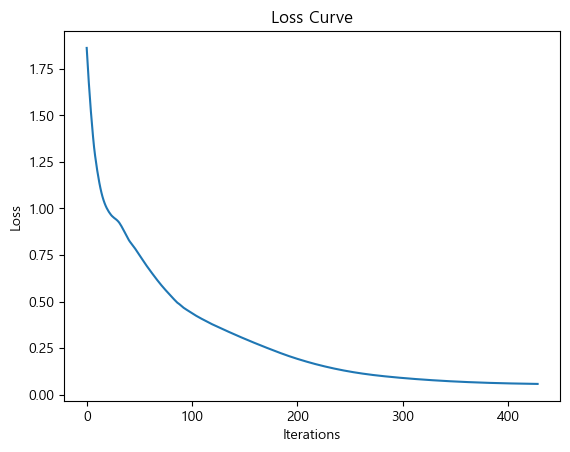

In [61]:
# 5. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 정확도: {accuracy:.4f}")
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

# 6. 학습 곡선 시각화
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

### 왜 은닉층의 노드 개수를 64개, 32개로 설정하는 걸까? 

> iris 데이터의 feature는 4개 뿐인데 굳이 왜 노드 개수를 64개로 늘리는 걸까? <br>
> 무작정 노드 개수를 늘리면 성능이 좋아지는 걸까? 

### Quiz5.

> 유방암 진단 데이터를 활용하여 심층 신경망 학습 코드를 구현하시오

In [292]:
from sklearn.datasets import load_breast_cancer
breast_X, breast_y = load_breast_cancer(return_X_y=True)

from sklearn.datasets import load_digits
num_X, num_y = load_digits(return_X_y=True)

In [282]:
scaler = StandardScaler()
scaler.fit_transform(breast_X)

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [293]:
breast_X /= 1000

In [161]:
num_X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [294]:
x_train, x_test, y_train, y_test = train_test_split(breast_X, breast_y, test_size=0.2, random_state=63)

mpl = MLPClassifier(hidden_layer_sizes=(128, 32),
                    activation='relu',
                    solver='adam',
                    max_iter=5000,
                    random_state=33)

mpl.fit(x_train, y_train)
y_pred = mpl.predict(x_test)

In [150]:
x_train, x_test, y_train, y_test = train_test_split(num_X, num_y, test_size=0.2, random_state=42)

mpl = MLPClassifier(hidden_layer_sizes=(256, 128),
                    activation='relu',
                    solver='adam',
                    max_iter=500,
                    random_state=42)

mpl.fit(x_train, y_train)
y_pred = mpl.predict(x_test)

테스트 정확도: 0.9825

분류 리포트:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.97      1.00      0.98        64

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



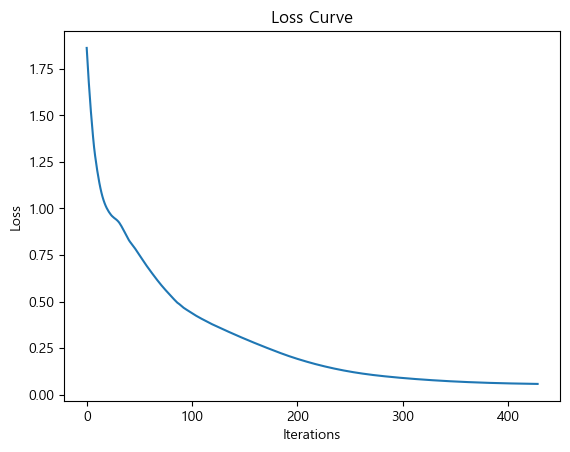

In [295]:
# 5. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 정확도: {accuracy:.4f}")
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

# 6. 학습 곡선 시각화
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

## <a id='six'>6. 딥러닝 프레임 워크 소개</a><br> 

### 1. TensorFlow
> Google에서 개발한 딥러닝 프레임워크 (2015년 공개)

```
✔ 특징

확장성: 대규모 모델 학습 및 배포에 최적화됨.
TF Lite, TF.js: 모바일/웹 환경에서도 실행 가능.
Graph 기반: 계산 그래프를 먼저 정의하고 실행하는 방식 (TF 2.0부터는 PyTorch 스타일의 즉시 실행(Eager Execution) 지원).
Google의 강력한 지원: TPU(텐서 프로세싱 유닛) 활용 가능.
✔ 장점
✅ 산업용 배포에 강함 (Google, 기업들이 많이 사용).
✅ TensorFlow Extended(TFX)로 엔드투엔드(End-to-End) 파이프라인 구축 가능.
✅ TensorFlow Lite, TensorFlow.js 지원으로 모바일/웹 적용 가능.

✔ 단점
❌ 코드가 PyTorch보다 다소 복잡함 (초기에는 직관적이지 않았음).
❌ PyTorch 대비 유연성이 떨어질 수 있음.

📌 TensorFlow는 이런 경우 추천!
🔹 대규모 모델 배포 및 프로덕션(Production) 환경
🔹 Google Cloud, TPUs를 활용한 모델 최적화
🔹 모바일/웹에 적용하려는 경우
```

### 2. PyTorch
> Facebook에서 개발한 딥러닝 프레임워크 (2016년 공개)

```
✔ 특징

직관적인 코드: Numpy 스타일의 연산을 지원하여 배우기 쉽고 디버깅이 쉬움.
Dynamic Computation Graph: 실행할 때마다 그래프를 동적으로 구성 (즉시 실행 방식).
강력한 GPU 가속 지원: CUDA 활용이 쉽고 최적화가 잘 되어 있음.
PyTorch Lightning: 복잡한 모델을 더 쉽게 관리할 수 있는 고수준 API 지원.
✔ 장점
✅ 코드가 직관적이고 사용하기 쉬움 (연구자들에게 인기 많음).
✅ Dynamic Graph로 디버깅이 편리함.
✅ PyTorch Lightning, Hugging Face 등 다양한 생태계 지원.

✔ 단점
❌ TensorFlow만큼 엔드투엔드 배포(Production) 환경이 강하지 않음.
❌ 산업에서 쓰이는 비율은 TensorFlow보다 낮았지만, 최근에는 많이 사용됨.

📌 PyTorch는 이런 경우 추천!
🔹 연구 및 프로토타이핑(빠르게 실험하는 환경)
🔹 딥러닝 모델을 학습 및 분석하는 과정이 필요한 경우
🔹 코드를 직관적으로 작성하고 싶은 경우
```

### 3. Keras
> 원래 독립적인 프레임워크였지만, 현재는 TensorFlow의 고수준 API로 통합됨.

```
✔ 특징

TensorFlow 기반: 현재 tf.keras로 통합되어 TensorFlow의 일부가 됨.
초보자 친화적: 단 몇 줄의 코드로 딥러닝 모델을 쉽게 만들 수 있음.
추상화된 API: 복잡한 딥러닝 구조를 쉽게 구현 가능.
✔ 장점
✅ TensorFlow 기반이므로 배포 및 프로덕션에 용이.
✅ 코드가 간결하고 배우기 쉬움.
✅ 빠른 프로토타이핑(Prototype) 및 간단한 실험에 유리함.

✔ 단점
❌ 너무 추상화되어 있어서 세부적인 컨트롤이 어려울 수 있음.
❌ PyTorch보다 연구용으로 활용하기 어려움.

📌 Keras는 이런 경우 추천!
🔹 딥러닝 초보자 (빠르게 실습하고 싶은 경우)
🔹 간단한 신경망을 빠르게 구현하고 싶은 경우
🔹 TensorFlow와 연동하여 배포까지 고려하는 경우
```

특징|	TensorFlow|	PyTorch|	Keras
---|---|---|---
출시 연도|	2015|	2016|	2015
개발사|	Google|	Facebook|	Google (현재 TensorFlow 일부)
사용 방식|	Graph 기반|	Dynamic Graph|	API 추상화
코드 직관성|	어렵지만 개선됨	| 매우 직관적|	가장 쉬움
모델 배포|	엔드투엔드 가능|	상대적으로 부족|	TensorFlow 기반으로 배포 가능
GPU 지원|	CUDA / TPU|	CUDA|	CUDA (TF 기반)
연구용|	연구보다는 배포용|	연구/실험 최적화|	초보자용
산업 활용도|	기업에서 많이 사용|	연구자들이 선호	간단한 모델용
추천 대상|	기업, 배포용|	연구, 실험|	초보자, 간단한 모델

In [339]:
import pandas as pd

data = pd.read_csv('C:\\Users\\human\\ku-python\\Ch12\\weatherAUS.csv')
data = pd.DataFrame(data)
data.drop(columns=['Date', 'Evaporation', 'Sunshine'], inplace=True)

In [328]:
data.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [340]:
data_encoded = pd.get_dummies(data, columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow'], drop_first=True)

In [323]:
data['RainTomorrow'].dropna(inplace=True)

In [341]:
data_encoded.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,False,False,False,False,False,False,False,True,False,False
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,False,False,False,False,False,False,False,True,False,False
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,...,False,False,False,False,False,False,False,False,False,False


numpy.bool_

In [353]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Columns: 109 entries, MinTemp to RainTomorrow_Yes
dtypes: bool(95), float64(14)
memory usage: 28.7 MB


In [358]:
data_encoded.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm',
       ...
       'WindDir3pm_S', 'WindDir3pm_SE', 'WindDir3pm_SSE', 'WindDir3pm_SSW',
       'WindDir3pm_SW', 'WindDir3pm_W', 'WindDir3pm_WNW', 'WindDir3pm_WSW',
       'RainToday_Yes', 'RainTomorrow_Yes'],
      dtype='object', length=109)

In [354]:
data_encoded.fillna(data_encoded.mean(), inplace=True)

In [355]:
data_encoded.isna().sum()

MinTemp             0
MaxTemp             0
Rainfall            0
WindGustSpeed       0
WindSpeed9am        0
                   ..
WindDir3pm_W        0
WindDir3pm_WNW      0
WindDir3pm_WSW      0
RainToday_Yes       0
RainTomorrow_Yes    0
Length: 109, dtype: int64

In [356]:
data_encoded.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,False,False,False,False,False,False,False,True,False,False
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,False,False,False,False,False,False,False,True,False,False
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data_encoded.drop(columns=['RainTomorrow_Yes']), data_encoded['RainTomorrow_Yes'], test_size=0.2, random_state=63)

mpl = MLPClassifier(hidden_layer_sizes=(512, 128),
                    activation='relu',
                    solver='adam',
                    max_iter=500,
                    early_stopping=True
                    random_state=33)

mpl.fit(x_train, y_train)
y_pred = mpl.predict(x_test)

c:\Users\human\anaconda3\envs\tf\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
# 5. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 정확도: {accuracy:.4f}")
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

# 6. 학습 곡선 시각화
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()